# 01 · Severson et al. (2019) cycle-life data

**Week 1:** load the 124 cells correctly and build intuition before any modelling.

By the end of this notebook you should have three figures in `results/figures/`:

1. Capacity fade for every cell, coloured by cycle life
2. The distribution of cycle life across the train and test sets
3. ΔQ₁₀₀₋₁₀(V) curves, the signal the paper's best feature is built from

In [1]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

from src.load_data import convert_batches, load_cells, split_keys, cell_table
from src.features import V_GRID, delta_q, log_var_delta_q

RAW = ROOT / "data" / "raw"
PROCESSED = ROOT / "data" / "processed"
FIGURES = ROOT / "results" / "figures"
FIGURES.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})

## 0 · Convert the .mat files (run once)

Put the three main batch files in `data/raw/`:

- `2017-05-12_batchdata_updated_struct_errorcorrect.mat`
- `2017-06-30_batchdata_updated_struct_errorcorrect.mat`
- `2018-04-12_batchdata_updated_struct_errorcorrect.mat`

This takes several minutes and needs a few GB of RAM. `max_cycle=100` keeps within-cycle curves only up to cycle 100, which is all the features need. The per-cycle summary is always kept for every cycle. You can also run it from a terminal: `python -m src.load_data`.

In [2]:
if not (PROCESSED / "batch3.pkl").exists():
    convert_batches(RAW, PROCESSED, max_cycle=100)
else:
    print("Pickles already exist; skipping conversion.")

Pickles already exist; skipping conversion.


## 1 · Load and sanity-check

Expect **124 cells**, split **41 train / 43 test / 40 secondary test**. If the numbers differ, stop and find out why before going further.

In [3]:
cells = load_cells(PROCESSED)
table = cell_table(cells)
splits = split_keys(cells)

print(f"{len(cells)} cells")
print(table["split"].value_counts().to_string())
assert len(cells) == 124, "Expected 124 cells after cleaning"
table.head()

124 cells
split
test              43
train             41
secondary_test    40


,batch,charge_policy,cycle_life,split
cell,,,,
b1c0,b1,3.6C(80%)-3.6C,1852.0,test
b1c1,b1,3.6C(80%)-3.6C,2160.0,train
b1c2,b1,3.6C(80%)-3.6C,2237.0,test
b1c3,b1,4C(80%)-4C,1434.0,train
b1c4,b1,4C(80%)-4C,1709.0,test


In [4]:
# Peek inside one cell to see the structure
example = cells[next(iter(cells))]
print("Top-level keys:", list(example))
print("Summary fields:", list(example["summary"]))
print("Cycle fields:  ", list(example["cycles"]["10"]))
print("Qdlin length:  ", len(example["cycles"]["10"]["Qdlin"]), "(should match V_GRID:", len(V_GRID), ")")

Top-level keys: ['cycle_life', 'charge_policy', 'summary', 'cycles', 'cycles_truncated']
Summary fields: ['IR', 'QC', 'QD', 'Tavg', 'Tmin', 'Tmax', 'chargetime', 'cycle']
Cycle fields:   ['I', 'Qc', 'Qd', 'Qdlin', 'T', 'Tdlin', 'V', 'dQdV', 't']
Qdlin length:   1000 (should match V_GRID: 1000 )


In [5]:
table["cycle_life"].describe()

count     124.000000
mean      801.637097
std       379.717082
min       148.000000
25%       498.750000
50%       736.500000
75%       946.500000
max      2237.000000
Name: cycle_life, dtype: float64

In [6]:

table["charge_policy"].nunique()

69

In [7]:
by_policy = table.groupby("charge_policy")["cycle_life"].agg(["count", "min", "max"])
print(by_policy["count"].value_counts().sort_index())   # how many policies have 1, 2, 3+ cells

reps = by_policy[by_policy["count"] >= 2]
print((reps["max"] / reps["min"]).describe())            # spread between "identical" cells

print("\n")

print(table["charge_policy"].nunique(), "unique charge policies" + "\n")

print((table.groupby("charge_policy")["split"].nunique() > 1).sum(), "policies appear in more than one split")

count
1    43
2    17
3     3
4     1
5     1
6     1
7     1
8     2
Name: count, dtype: int64
count    26.000000
mean      1.263790
std       0.319670
min       1.005834
25%       1.057035
50%       1.165621
75%       1.397494
max       2.380074
dtype: float64


69 unique charge policies

18 policies appear in more than one split


*Notes:*

124 cells, cycle life 148–2,237 (≈15× range), median ~737, mean ~802, so right-skewed by a few long-lived cells. X distinct charging policies, so roughly 1–3 cells per policy. Because the spread is multiplicative, model log(cycle life) and judge models on % error rather than absolute cycles.

69 policies: 43 tested once, 17 twice, 2 policies with 8 cells (16 cells, 13% of the data). Among the 26 replicated policies, the longest/shortest life ratio has median 1.17 (IQR 1.06–1.40), so cells charged identically typically differ by ~17%: cell-to-cell variability. Knowing the policy alone would therefore leave ~8% error per cell, which makes the paper's 9.1% from early cycles alone impressive. Max ratio 2.38: check whether it involves the paused/resumed batch 1 cells. 18 policies span more than one split, but most test cells (single-tested policies) are still unseen conditions.

## 2 · Capacity fade for every cell

Discharge capacity against cycle number, coloured by cycle life on a log scale. The dashed line is 80% of the 1.1 Ah nominal capacity, the end-of-life threshold.

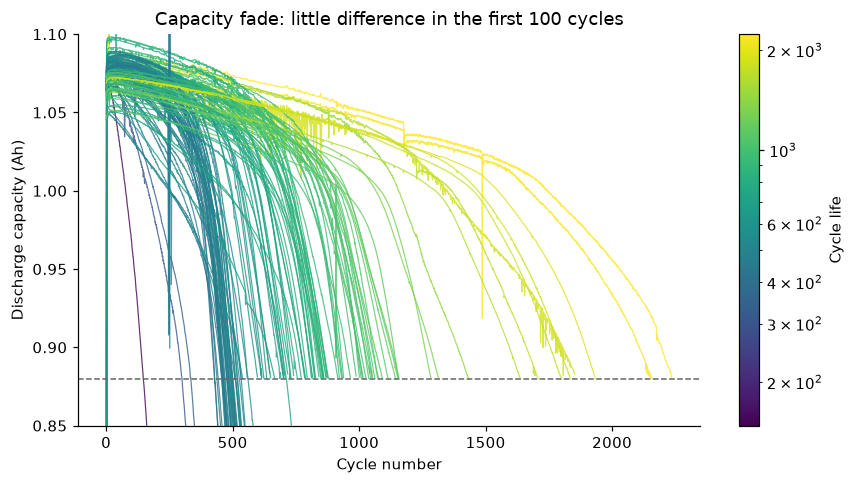

In [8]:
life = table["cycle_life"]
norm = LogNorm(vmin=life.min(), vmax=life.max())
cmap = plt.cm.viridis

fig, ax = plt.subplots(figsize=(8, 4.5))
for key, cell in cells.items():
    s = cell["summary"]
    ax.plot(s["cycle"], s["QD"], color=cmap(norm(cell["cycle_life"])), lw=0.8, alpha=0.8)
ax.axhline(0.88, ls="--", lw=1, color="0.4")
ax.set_ylim(0.85, 1.1)  # summary data has a few spikes; zoom to the useful range
ax.set_xlabel("Cycle number")
ax.set_ylabel("Discharge capacity (Ah)")
ax.set_title("Capacity fade: little difference in the first 100 cycles")
fig.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=cmap), ax=ax, label="Cycle life")
fig.tight_layout()
fig.savefig(FIGURES / "01_capacity_fade.png", dpi=200)

Cycles of 0–100 (`ax.set_xlim(0, 100)`). Could you predict lifetime from capacity alone at that stage? Why does that make this problem hard?

*Notes:*

Over cycles 0–100, almost all cells sit flat at ~1.04–1.09 Ah (<1% fade), far from the 0.88 Ah end-of-life threshold. Colours are interleaved: starting capacity doesn't rank cells by lifetime. Only the very shortest-lived cell (~200 cycles) shows visible early fade. Capacity alone can't predict lifetime at this stage, because the early fade is about the same size as measurement noise and degradation is non-linear (flat, then a late "knee"), so extrapolating early fade would overestimate life. That's the case for using the full voltage curve (ΔQ(V)) instead. Data quirks to handle in week 2: noise spikes (~cycles 10 and 75) and a first-cycle artefact.

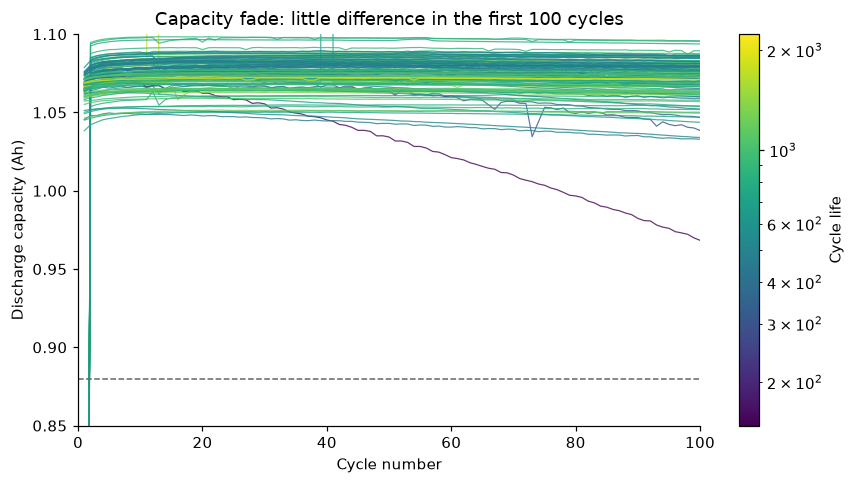

In [9]:

fig, ax = plt.subplots(figsize=(8, 4.5))
for key, cell in cells.items():
    s = cell["summary"]
    ax.plot(s["cycle"], s["QD"], color=cmap(norm(cell["cycle_life"])), lw=0.8, alpha=0.8)
ax.axhline(0.88, ls="--", lw=1, color="0.4")
ax.set_xlim(0, 100)
ax.set_ylim(0.85, 1.1)  # summary data has a few spikes; zoom to the useful range
ax.set_xlabel("Cycle number")
ax.set_ylabel("Discharge capacity (Ah)")
ax.set_title("Capacity fade: little difference in the first 100 cycles")
fig.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=cmap), ax=ax, label="Cycle life")
fig.tight_layout()

## 3 · How cycle life is distributed across the splits

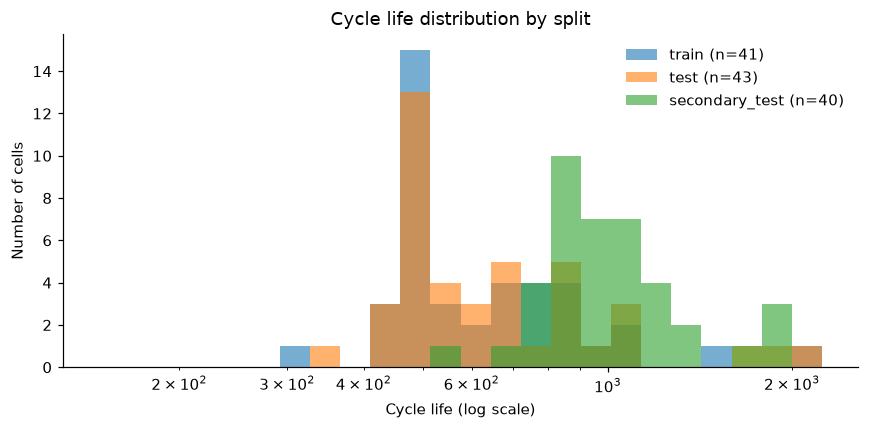

In [10]:
bins = np.logspace(np.log10(life.min()), np.log10(life.max()), 25)
fig, ax = plt.subplots(figsize=(8, 4))
for split, colour in zip(["train", "test", "secondary_test"], ["C0", "C1", "C2"]):
    ax.hist(table.loc[splits[split], "cycle_life"], bins=bins, alpha=0.6, color=colour,
            label=f"{split} (n={len(splits[split])})")
ax.set_xscale("log")
ax.set_xlabel("Cycle life (log scale)")
ax.set_ylabel("Number of cells")
ax.set_title("Cycle life distribution by split")
ax.legend(frameon=False)
fig.tight_layout()
fig.savefig(FIGURES / "01_cycle_life_hist.png", dpi=200)

*Notes:*

Train and test share almost the same distribution (by construction: alternating cells from batches 1–2), peaking around 500 cycles, with most cells between 400 and 900. The secondary test set (batch 3, tested in 2018) is shifted to longer lives (mostly 700–1,300, with a cluster near 1,800), while training has few cells above ~1,200. Expect higher error on the secondary set: the model must extrapolate to long lives, may under-predict them, and may be affected by batch effects (chamber, cell lot, timing). Report the secondary test error separately as the most realistic measure of performance on genuinely new cells.

## 4 · ΔQ₁₀₀₋₁₀(V): the signal hidden in the discharge curve

For each cell, subtract the cycle-10 discharge curve from the cycle-100 curve on the same voltage grid. Capacity barely changes over these cycles, but the *shape* of this difference does.

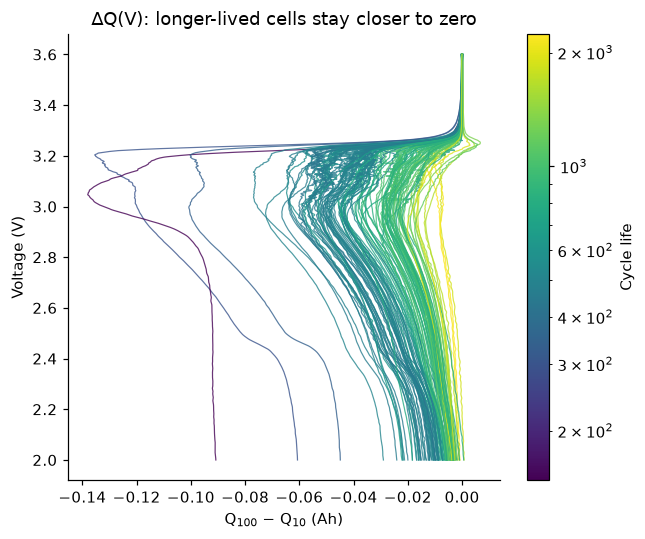

In [11]:
fig, ax = plt.subplots(figsize=(6, 5))
for key, cell in cells.items():
    ax.plot(delta_q(cell), V_GRID, color=cmap(norm(cell["cycle_life"])), lw=0.8, alpha=0.8)
ax.set_xlabel("Q$_{100}$ − Q$_{10}$ (Ah)")
ax.set_ylabel("Voltage (V)")
ax.set_title("ΔQ(V): longer-lived cells stay closer to zero")
fig.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=cmap), ax=ax, label="Cycle life")
fig.tight_layout()
fig.savefig(FIGURES / "01_delta_q_curves.png", dpi=200)

*Notes:*

Above ~3.3 V, ΔQ₁₀₀₋₁₀(V) is ~0 for all cells; below ~3.25 V the curves fan out in order of lifetime. Long-lived cells stay within ~−0.01 Ah of zero, medium ones reach −0.02 to −0.05 Ah, and the shortest-lived swing to −0.14 Ah with distorted shapes around 2.9–3.1 V. Unlike total capacity, the curve shape after 100 cycles already ranks cells by future life. Statistic: log₁₀ variance of ΔQ(V), which captures both size and unevenness of the change, ignores constant offsets, and handles the orders-of-magnitude range. Mean ≈ capacity fade (weak) and minimum = one noisy point are worse candidates; I'll test them as features in week 2. One curve shows a small positive excursion near 3.2–3.3 V (likely noise).

## 5 · One feature against cycle life

The paper's strongest single feature is log₁₀ of the variance of ΔQ(V). If the relationship looks close to linear here, a one-feature linear model will already do well.

Pearson r between log var(ΔQ) and log cycle life: -0.93


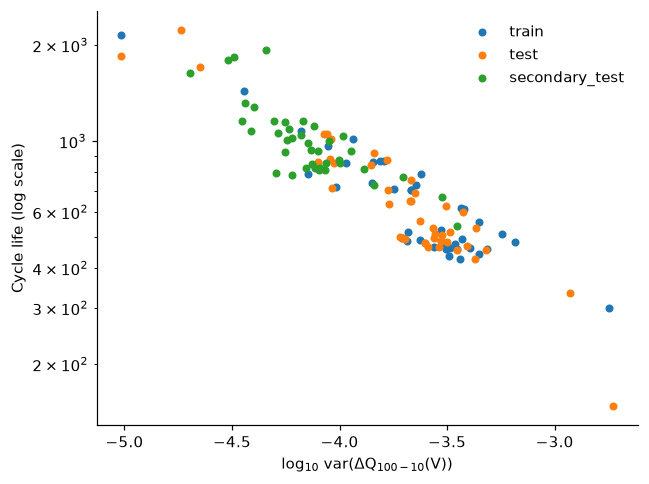

In [12]:
table["log_var_dq"] = [log_var_delta_q(cells[k]) for k in table.index]

fig, ax = plt.subplots(figsize=(6, 4.5))
for split, colour in zip(["train", "test", "secondary_test"], ["C0", "C1", "C2"]):
    sub = table.loc[splits[split]]
    ax.scatter(sub["log_var_dq"], sub["cycle_life"], s=18, color=colour, label=split)
ax.set_yscale("log")
ax.set_xlabel("log$_{10}$ var(ΔQ$_{100-10}$(V))")
ax.set_ylabel("Cycle life (log scale)")
ax.legend(frameon=False)
fig.tight_layout()
fig.savefig(FIGURES / "01_logvar_vs_life.png", dpi=200)

r = np.corrcoef(table["log_var_dq"], np.log10(table["cycle_life"]))[0, 1]
print(f"Pearson r between log var(ΔQ) and log cycle life: {r:.2f}")

With the corrected cycles (10 and 100), Pearson r = −0.93 between log₁₀ var(ΔQ₁₀₀₋₁₀(V)) and log₁₀ cycle life (r² ≈ 0.86, up from −0.91 before the index fix). One feature from the first 100 cycles explains most of the variation in lifetime. All three splits follow the same trend. The few points at the extremes (~−5.0 and ~−2.8) will have high leverage in a linear fit.

In [13]:
tr = table.loc[splits["train"]]
slope, intercept = np.polyfit(tr["log_var_dq"], np.log10(tr["cycle_life"]), 1)
table["pred_life"] = 10 ** (intercept + slope * table["log_var_dq"])
table["resid_pct"] = 100 * (table["pred_life"] - table["cycle_life"]) / table["cycle_life"]

print(f"Fit: log10(life) = {intercept:.2f} + {slope:.2f} × log_var_dq")
table.reindex(table["resid_pct"].abs().sort_values(ascending=False).index)[
    ["batch", "charge_policy", "split", "cycle_life", "pred_life", "resid_pct"]].head(8)

Fit: log10(life) = 1.35 + -0.40 × log_var_dq


,batch,charge_policy,split,cycle_life,pred_life,resid_pct
cell,,,,,,
b2c1,b2,2C(10%)-6C,test,148.0,266.356594,79.970672
b3c38,b3,5C(67%)-4C-newstructure,secondary_test,1935.0,1160.972717,-40.001410
b3c40,b3,5.6C(19%)-4.6C-newstructure,secondary_test,796.0,1112.343471,39.741642
b3c41,b3,5.6C(36%)-4.3C-newstructure,secondary_test,786.0,1038.276575,32.096256
b2c45,b2,6C(4%)-4.75C,train,487.0,639.852995,31.386652
b2c20,b2,4.4C(8%)-4.85C,test,502.0,659.102234,31.295266
b2c29,b2,4.9C(69%)-4.25C,train,498.0,651.912559,30.906136
b2c24,b2,4.8C(80%)-4.8C,test,495.0,644.174107,30.136183


Train-only fit: log₁₀(life) = 1.35 − 0.40·log var(ΔQ), so a 10× increase in variance ≈ 2.5× shorter life. Largest misses: b2c1 (2C(10%)-6C, 148 vs 266 predicted, +80%), the harshest policy, whose degradation accelerates faster than the early signal shows. b3c38 (1,935 vs 1,161, −40%): long-lived cells pulled towards the mean. The other big misses are batch 2 and 3 cells over-predicted by ~30–40%, mostly lives of 480–800 under high-current policies.

In [14]:
table.groupby("batch")["resid_pct"].agg(["mean", lambda s: s.abs().mean()])

,mean,<lambda_0>
batch,,
b1,-8.462677,12.281730
b2,14.267981,16.504111
b3,-0.777507,11.415496


Mean residual by batch: b1 −8.5% (lives longer than predicted), b2 +14.3% (dies sooner than predicted), b3 −0.8% (unbiased). Mean absolute error: b1 12.3%, b2 16.5%, b3 11.4%. So the single feature carries a batch-dependent bias: the same ΔQ signal means a different lifetime in different batches. Possible causes: batch 2's aggressive full-range policies, and the 5 spliced batch 1 cells, whose capacity recovered after the pause. To test the second, recompute the b1 mean without b1c0–b1c4. Note these errors are from a one-feature line fitted on train and applied to all cells, so it's a rough preview, not a proper test error. Compare with the paper's "variance model" row in Table 1.

In [15]:
table["charge_policy"].str.contains("newstructure").groupby(table["batch"]).sum()

batch
b1     0
b2     0
b3    40
Name: charge_policy, dtype: int64

"newstructure" appears in all 40 batch 3 policies and none in batches 1–2, so it marks batch 3's revised test protocol, not anything special about b3c38. Batch 3 is the least biased batch despite the protocol change, which is encouraging for the secondary test set.

## 6 · Summary of Findings

- 124 cells, 69 charge policies (43 tested once), cycle life 148–2,237 (median 737, right-skewed), so model log life and judge on % error.
- Cells on identical policies differ by ~17% in life (median), a noise floor from cell-to-cell variability.
- Capacity alone can't separate cells over cycles 1–100 (<1% fade, about the same size as noise).
- The shape of the discharge curve can: log var(ΔQ₁₀₀₋₁₀(V)) correlates at r = −0.93 with log cycle life, reproducing the paper's key result.
- A one-feature fit shows batch-dependent bias (b2 over-predicted by ~14%), which motivates the extra features in week 2.
- The secondary test set (batch 3) has longer lives and a revised protocol, but follows the same trend.